In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import time

df = pd.read_hdf("../reports/test_scored.h5", "df")
print(f"Shape: {df.shape}")

Shape: (17574, 94)


In [ ]:
TARGET = "installed_decision"

# ── LEAK-FREE FEATURES ONLY ──
#
# EXCLUDED (LEAKY) — built from TEST window via build_partner_ops_vector():
#   se_30d, decline_rate_30d, installs_30d, declines_30d, total_decisions,
#   median_response_min, mean_response_min, expected_daily_slots, active_days,
#   nmbr_active_leads, long_held_leads_24h, queue_velocity,
#   active_tickets, median_tat_min, max_tat_min, ticket_resolution_rate,
#   late_arrive_median, late_arrive_max, late_severity_max, late_close_penalty,
#   plan_created_rate, planning_strength,
#   operational_score, capacity_score, reliability_score, infrastructure_score,
#   composite_score, spatial_shrunk (contains ops), confidence_tier, r_serviceable
#
# SAFE — all derived from TRAINING data or infrastructure:

FEATURES = [
    # SPATIAL — Gaussian KDE from training sources
   # "predicted_field_hex",
    "contested_field",
    'predicted_field_hex_all_wmean',
    # HEX — training install/decline counts, shrunk
    # "parent_se",
    # "parent_total",
    "parent_color_numeric",
    "n_covering_partners",
    'dist_to_best_hex_center',
    # HOP — training hex neighbor SE aggregates
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",
    # BOUNDARY — training cluster geometry
    "dist_to_boundary_edge_point_hex",
    "dist_to_cluster_center_point_hex",
    "depth_score_point_hex",
    "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    # GEOMETRIC PATTERN — from training install points around lead
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m",
    "dense_score", "gully_score", "sparse_score",
    # LEAD-LEVEL
    "hard_density",  # BallTree count from training settled decisions
    "min_dist",      # G1 distance to nearest router (infrastructure)
]

available = [f for f in FEATURES if f in df.columns]
missing = [f for f in FEATURES if f not in df.columns]
print(f"Using {len(available)} features, missing {len(missing)}: {missing}")

Using 29 features, missing 0: []


In [3]:
# ── PREP ──
X = df[available].copy()
y = df[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
X = X.fillna(-999)

print(f"Samples: {len(X)}, Features: {X.shape[1]}, Install rate: {y.mean():.4f}")

Samples: 17574, Features: 29, Install rate: 0.5962


In [4]:
# ── TRAIN / TEST SPLIT ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y.astype(int)
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print(f"Train SE: {y_train.mean():.4f}  Test SE: {y_test.mean():.4f}")

Train: 12301  Test: 5273
Train SE: 0.5961  Test SE: 0.5962


In [5]:
# ── FIT ──
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=50,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print(f"Train R²: {rf.score(X_train, y_train):.4f}")
print(f"Test  R²: {rf.score(X_test, y_test):.4f}\n\n")
# ── FEATURE IMPORTANCE ──
imp = pd.Series(rf.feature_importances_, index=available).sort_values(ascending=False)
print(imp.round(4).to_string())
print(f"\nTop 10:")
for feat, val in imp.head(10).items():
    bar = "█" * int(val * 200)
    print(f"  {feat:40s} {val:.4f} {bar}")

Train R²: 0.1222
Test  R²: 0.0588


contested_field                     0.0880
predicted_field_hex_all_wmean       0.0561
hop1_se_wmean                       0.0561
hull_area                           0.0551
se_confirmed                        0.0492
hard_density                        0.0430
min_dist                            0.0412
parent_color_numeric                0.0400
isolation_ratio                     0.0397
hop2_se_wmean                       0.0364
hop3_se_wmean                       0.0362
mean_dist_to_center_m               0.0354
total_area_boundaries               0.0314
mean_dist_to_edge_m                 0.0314
dist_to_boundary_edge_point_hex     0.0307
local_density                       0.0306
se_gradient_1to3                    0.0304
depth_score_point_hex               0.0290
n_covering_partners                 0.0285
dense_score                         0.0283
dist_to_cluster_center_point_hex    0.0283
local_anisotropy                    0.0271
spread_m          

In [6]:
# ── DECILE PERFORMANCE (TEST SET ONLY — honest eval) ──
preds = rf.predict(X_test)
eval_df = pd.DataFrame({"y": y_test.values, "pred": preds})
eval_df["decile"] = pd.qcut(eval_df["pred"], q=10, labels=False, duplicates="drop") + 1

decile_tbl = eval_df.groupby("decile").agg(
    n=("y", "count"),
    installs=("y", "sum"),
    pred_mean=("pred", "mean"),
).assign(se=lambda x: x.installs / x.n)

gap = decile_tbl["se"].iloc[-1] - decile_tbl["se"].iloc[0]
monotonic = all(decile_tbl["se"].diff().dropna() >= 0)

print(f"TEST SET decile gap: {gap:.4f}  Monotonic: {monotonic}")
print(decile_tbl.round(4))

TEST SET decile gap: 0.4470  Monotonic: False
          n  installs  pred_mean      se
decile                                  
1       528       187     0.4183  0.3542
2       527       225     0.5034  0.4269
3       527       285     0.5423  0.5408
4       527       317     0.5689  0.6015
5       528       319     0.5926  0.6042
6       527       328     0.6140  0.6224
7       527       326     0.6369  0.6186
8       527       359     0.6605  0.6812
9       527       375     0.6883  0.7116
10      528       423     0.7426  0.8011


In [7]:
# ══════════════════════════════════════════════
# CROSS EXPERIMENTATION — HGB HYPERPARAMETER SWEEP
# ══════════════════════════════════════════════

from itertools import product

param_grid = {
    "learning_rate": [0.02, 0.04, 0.07, 0.1],
    "max_depth": [3, 4, 6, 8],
    "min_samples_leaf": [30, 50, 100, 200],
    "l2_regularization": [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes": [15, 31, 63],
}

# Fixed params
fixed = dict(
    loss="squared_error",
    max_iter=1000,
    max_bins=255,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
)

# ── RANDOM SAMPLE FROM GRID (full grid = 768 combos) ──
np.random.seed(42)
all_combos = list(product(*param_grid.values()))
sample_idx = np.random.choice(len(all_combos), size=120, replace=False)
sampled = [all_combos[i] for i in sample_idx]

results = []
t0 = time.time()

for i, (lr, md, msl, l2, mln) in enumerate(sampled):
    params = dict(
        learning_rate=lr,
        max_depth=md,
        min_samples_leaf=msl,
        l2_regularization=l2,
        max_leaf_nodes=mln,
        **fixed,
    )
    m = HistGradientBoostingRegressor(**params)
    m.fit(X_train, y_train)
    
    tr = m.score(X_train, y_train)
    te = m.score(X_test, y_test)
    
    # decile gap on test
    preds = m.predict(X_test)
    edf = pd.DataFrame({"y": y_test.values, "p": preds})
    edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
    tbl = edf.groupby("d").agg(n=("y", "count"), inst=("y", "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    gap = tbl["se"].iloc[-1] - tbl["se"].iloc[0]
    mono = all(tbl["se"].diff().dropna() >= 0)
    
    results.append({
        "lr": lr, "max_depth": md, "min_samples_leaf": msl,
        "l2": l2, "max_leaf_nodes": mln,
        "n_iter": m.n_iter_, "train_r2": tr, "test_r2": te,
        "gap": gap, "mono": mono,
    })
    
    if (i + 1) % 20 == 0:
        elapsed = time.time() - t0
        print(f"  [{i+1}/120] {elapsed:.0f}s — best test R² so far: "
              f"{max(r['test_r2'] for r in results):.4f}")

total = time.time() - t0
print(f"\nDone — 120 experiments in {total:.0f}s")

res_df = pd.DataFrame(results).sort_values("test_r2", ascending=False)

  [20/120] 12s — best test R² so far: 0.0571
  [40/120] 22s — best test R² so far: 0.0571
  [60/120] 30s — best test R² so far: 0.0571
  [80/120] 45s — best test R² so far: 0.0571
  [100/120] 58s — best test R² so far: 0.0571
  [120/120] 66s — best test R² so far: 0.0571

Done — 120 experiments in 66s


In [8]:
# ── TOP 10 BY TEST R² ──
print(f"{'#':>3}  {'lr':>5}  {'depth':>5}  {'leaf':>5}  {'l2':>5}  {'nodes':>5}  "
      f"{'iters':>5}  {'train_r2':>8}  {'test_r2':>8}  {'gap':>7}  {'mono':>5}")
print("-" * 95)
for i, (_, r) in enumerate(res_df.head(10).iterrows()):
    print(f"{i+1:>3}  {r.lr:>5.2f}  {int(r.max_depth):>5}  {int(r.min_samples_leaf):>5}  "
          f"{r.l2:>5.1f}  {int(r.max_leaf_nodes):>5}  {int(r.n_iter):>5}  "
          f"{r.train_r2:>8.4f}  {r.test_r2:>8.4f}  {r.gap:>7.4f}  {str(r.mono):>5}")

  #     lr  depth   leaf     l2  nodes  iters  train_r2   test_r2      gap   mono
-----------------------------------------------------------------------------------------------
  1   0.02      8     30    2.0     31    297    0.2077    0.0571   0.4110  False
  2   0.04      8     30    0.5     63     98    0.2389    0.0569   0.4205   True
  3   0.02      6     30    0.5     31    198    0.1517    0.0568   0.4091  False
  4   0.02      8     30   10.0     63    138    0.1863    0.0563   0.4101   True
  5   0.04      8     50    5.0     63     85    0.1982    0.0556   0.4034  False
  6   0.04      6     30    0.5     63    146    0.2109    0.0555   0.4167   True
  7   0.02      4     50    5.0     15    537    0.1403    0.0552   0.4299   True
  8   0.02      6     50   10.0     31    247    0.1556    0.0552   0.4242  False
  9   0.04      4     30   10.0     31    269    0.1434    0.0549   0.3996  False
 10   0.02      8    100    5.0     15    263    0.1161    0.0549   0.4091  False


In [9]:
# ── FULL-DATA PREDICTION + COMPARISON ──
df["rf_score"] = rf.predict(df[available].fillna(-999))
df["rf_decile"] = pd.qcut(df["rf_score"], q=10, labels=False, duplicates="drop") + 1

full_tbl = df.groupby("rf_decile").agg(
    n=("mobile", "count"),
    installs=(TARGET, "sum"),
).assign(se=lambda x: x.installs / x.n)

full_gap = full_tbl["se"].iloc[-1] - full_tbl["se"].iloc[0]
full_mono = all(full_tbl["se"].diff().dropna() >= 0)
print(f"Full data — gap: {full_gap:.4f}  monotonic: {full_mono}")
print(full_tbl.round(4))

# Compare
def decile_gap(score_col):
    d = pd.qcut(df[score_col], q=10, labels=False, duplicates="drop") + 1
    tbl = df.groupby(d).agg(n=(TARGET, "count"), inst=(TARGET, "sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]
    return tbl["se"].iloc[-1] - tbl["se"].iloc[0], all(tbl["se"].diff().dropna() >= 0)

print(f"\n{'Score':25s}  {'Gap':>8s}  {'Mono':>5s}")
print("-" * 42)
for col in ["rf_score", "composite_score", "spatial_shrunk"]:
    if col in df.columns:
        g, m = decile_gap(col)
        print(f"{col:25s}  {g:8.4f}  {str(m):>5s}")

Full data — gap: 0.6092  monotonic: True
              n  installs      se
rf_decile                        
1          1758       498  0.2833
2          1757       642  0.3654
3          1757       828  0.4713
4          1758       953  0.5421
5          1757      1005  0.5720
6          1757      1102  0.6272
7          1758      1192  0.6780
8          1757      1304  0.7422
9          1757      1384  0.7877
10         1758      1569  0.8925

Score                           Gap   Mono
------------------------------------------
rf_score                     0.6092   True
spatial_shrunk               0.2527  False


In [10]:
# ══════════════════════════════════════════════
# CORRELATION ANALYSIS
# ══════════════════════════════════════════════

# 1. Each feature's correlation with target
feat_df = df[available + [TARGET]].copy()
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)

print("Correlation with installed_decision:\n")
for feat, val in corr_target.items():
    bar = "█" * int(abs(val) * 200)
    sign = "+" if val >= 0 else "-"
    print(f"  {sign}{abs(val):.4f}  {feat:40s}  {bar}")

Correlation with installed_decision:

  +0.1095  parent_color_numeric                      █████████████████████
  +0.1035  predicted_field_hex_all_wmean             ████████████████████
  +0.1026  contested_field                           ████████████████████
  +0.0985  hull_area                                 ███████████████████
  +0.0927  nmbr_overlap_clusters                     ██████████████████
  +0.0822  hop1_se_wmean                             ████████████████
  +0.0782  total_area_boundaries                     ███████████████
  +0.0700  se_gradient_1to3                          ██████████████
  +0.0658  spread_m                                  █████████████
  +0.0577  hop2_se_wmean                             ███████████
  +0.0408  se_confirmed                              ████████
  +0.0370  dense_score                               ███████
  +0.0277  hop3_se_wmean                             █████
  +0.0275  nearest_boundary_dist_m                   █████
  +0.0249  mea

In [11]:
# 2. Feature-to-feature: flag high collinearity (|r| > 0.7)
corr_matrix = df[available].corr()

high_corr = []
for i in range(len(available)):
    for j in range(i + 1, len(available)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            high_corr.append((available[i], available[j], round(r, 3)))

high_corr.sort(key=lambda x: -abs(x[2]))

print(f"Highly correlated pairs (|r| > 0.7): {len(high_corr)}\n")
for a, b, r in high_corr:
    print(f"  {r:+.3f}  {a}  <->  {b}")

Highly correlated pairs (|r| > 0.7): 12

  -0.963  dense_score  <->  sparse_score
  +0.882  hop3_se_wmean  <->  se_confirmed
  +0.822  contested_field  <->  predicted_field_hex_all_wmean
  +0.803  local_anisotropy  <->  gully_score
  +0.798  dist_to_cluster_center_point_hex  <->  depth_score_point_hex
  +0.775  hop2_se_wmean  <->  se_confirmed
  +0.764  hop1_se_wmean  <->  hop2_se_wmean
  +0.755  hull_area  <->  spread_m
  +0.752  hop1_se_wmean  <->  se_confirmed
  +0.748  hop2_se_wmean  <->  hop3_se_wmean
  +0.722  total_area_boundaries  <->  nmbr_overlap_clusters
  +0.712  n_covering_partners  <->  hard_density


In [12]:
# 3. Importance vs correlation comparison
comparison = pd.DataFrame({
    "importance": imp,
    "corr_target": corr_target,
}).dropna().sort_values("importance", ascending=False)

print(f"{'Feature':40s}  {'Imp':>6s}  {'Corr':>6s}")
print("-" * 56)
for feat, row in comparison.iterrows():
    print(f"{feat:40s}  {row['importance']:6.4f}  {row['corr_target']:+6.4f}")

Feature                                      Imp    Corr
--------------------------------------------------------
contested_field                           0.0880  +0.1026
predicted_field_hex_all_wmean             0.0561  +0.1035
hop1_se_wmean                             0.0561  +0.0822
hull_area                                 0.0551  +0.0985
se_confirmed                              0.0492  +0.0408
hard_density                              0.0430  -0.0095
min_dist                                  0.0412  -0.0102
parent_color_numeric                      0.0400  +0.1095
isolation_ratio                           0.0397  -0.0042
hop2_se_wmean                             0.0364  +0.0577
hop3_se_wmean                             0.0362  +0.0277
mean_dist_to_center_m                     0.0354  +0.0088
total_area_boundaries                     0.0314  +0.0782
mean_dist_to_edge_m                       0.0314  +0.0249
dist_to_boundary_edge_point_hex           0.0307  -0.0036
local_density   

In [13]:
# ── 1. SINGLE TREE VISUALIZATION (text) ──
from sklearn.tree import export_text

# Pick one shallow tree from the forest
single_tree = rf.estimators_[0]
tree_text = export_text(single_tree, feature_names=available, max_depth=4)
print(tree_text)

|--- nearest_boundary_dist_m <= 0.12
|   |--- predicted_field_hex_all_wmean <= -0.41
|   |   |--- contested_field <= -0.50
|   |   |   |--- hull_area <= 3532.10
|   |   |   |   |--- mean_dist_to_center_m <= 347.11
|   |   |   |   |   |--- value: [0.45]
|   |   |   |   |--- mean_dist_to_center_m >  347.11
|   |   |   |   |   |--- value: [0.21]
|   |   |   |--- hull_area >  3532.10
|   |   |   |   |--- dense_score <= 0.15
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- dense_score >  0.15
|   |   |   |   |   |--- truncated branch of depth 7
|   |   |--- contested_field >  -0.50
|   |   |   |--- se_confirmed <= 0.02
|   |   |   |   |--- total_area_boundaries <= 0.41
|   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |--- total_area_boundaries >  0.41
|   |   |   |   |   |--- value: [0.70]
|   |   |   |--- se_confirmed >  0.02
|   |   |   |   |--- hop3_se_wmean <= 0.37
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- hop3

In [14]:
# ── RF INTERPRETABILITY VISUALS ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.inspection import partial_dependence

plt.rcParams.update({
    "figure.facecolor": "#0a0e17",
    "axes.facecolor": "#111827",
    "axes.edgecolor": "#1e293b",
    "axes.labelcolor": "#9ca3af",
    "xtick.color": "#6b7280",
    "ytick.color": "#6b7280",
    "text.color": "#e2e8f0",
    "grid.color": "#1e293b",
    "font.family": "monospace",
    "font.size": 10,
})
AMBER = "#f0b429"
BLUE = "#60a5fa"
GREEN = "#10b981"
RED = "#ef4444"
PURPLE = "#a78bfa"
CYAN = "#22d3ee"
GRAY = "#4a5568"

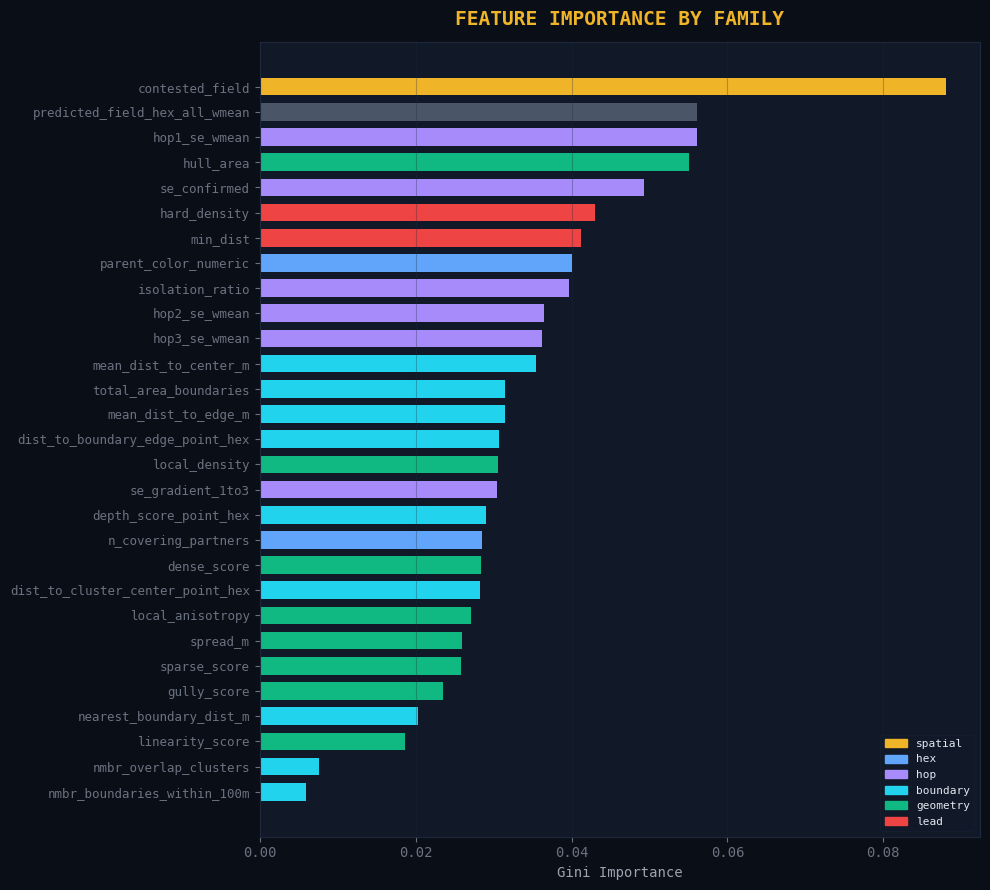

In [15]:
# ── 1. FEATURE IMPORTANCE — horizontal bar, colored by family ──
family_map = {
    "contested_field": "spatial", "predicted_field_hex": "spatial",
    "parent_se": "hex", "parent_color_numeric": "hex", "parent_total": "hex", "n_covering_partners": "hex",
    "hop1_se_wmean": "hop", "hop2_se_wmean": "hop", "hop3_se_wmean": "hop",
    "se_gradient_1to3": "hop", "se_confirmed": "hop", "isolation_ratio": "hop",
    "dist_to_boundary_edge_point_hex": "boundary", "dist_to_cluster_center_point_hex": "boundary",
    "depth_score_point_hex": "boundary", "mean_dist_to_edge_m": "boundary",
    "mean_dist_to_center_m": "boundary", "total_area_boundaries": "boundary",
    "nmbr_overlap_clusters": "boundary", "nearest_boundary_dist_m": "boundary",
    "nmbr_boundaries_within_100m": "boundary",
    "local_anisotropy": "geometry", "local_density": "geometry", "hull_area": "geometry",
    "linearity_score": "geometry", "spread_m": "geometry",
    "dense_score": "geometry", "gully_score": "geometry", "sparse_score": "geometry",
    "hard_density": "lead", "min_dist": "lead",
}
fam_colors = {"spatial": AMBER, "hex": BLUE, "hop": PURPLE, "boundary": CYAN, "geometry": GREEN, "lead": RED}

imp_sorted = imp.sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f, ""), GRAY) for f in imp_sorted.index]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(len(imp_sorted)), imp_sorted.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp_sorted)))
ax.set_yticklabels(imp_sorted.index, fontsize=9)
ax.set_xlabel("Gini Importance")
ax.set_title("FEATURE IMPORTANCE BY FAMILY", fontsize=14, fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

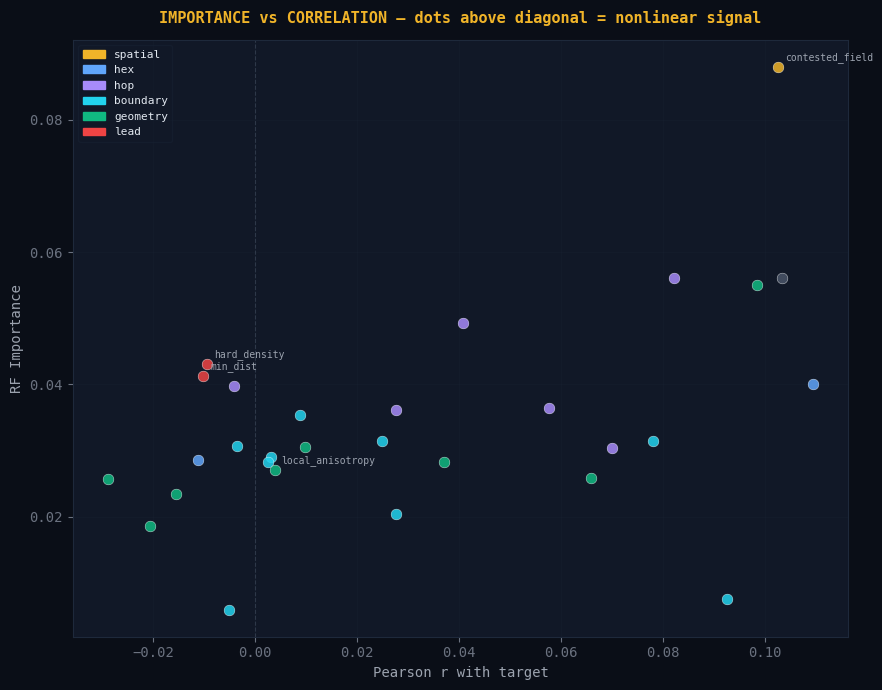

In [16]:
# ── 2. IMPORTANCE vs CORRELATION scatter ──
fig, ax = plt.subplots(figsize=(9, 7))

for feat in imp.index:
    c = fam_colors.get(family_map.get(feat, ""), GRAY)
    corr_val = corr_target.get(feat, 0)
    imp_val = imp[feat]
    ax.scatter(corr_val, imp_val, c=c, s=60, alpha=0.85, edgecolor="white", linewidth=0.3, zorder=3)

# Label top divergent features (high imp, low/negative corr)
for feat in ["parent_total", "min_dist", "hard_density", "local_anisotropy", "contested_field", "parent_se"]:
    if feat in imp.index:
        ax.annotate(feat, (corr_target[feat], imp[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5, 5), textcoords="offset points")

ax.axvline(0, color=GRAY, linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Pearson r with target")
ax.set_ylabel("RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION — dots above diagonal = nonlinear signal",
             fontsize=11, fontweight="bold", color=AMBER, pad=12)
ax.grid(alpha=0.2)

patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3, edgecolor="#1e293b")
plt.tight_layout()
plt.show()

In [18]:
# ── REFIT CONFIG #3 ──
hgb3 = HistGradientBoostingRegressor(
    learning_rate=0.10, max_depth=8, min_samples_leaf=200,
    l2_regularization=5.0, max_leaf_nodes=63, **fixed,
)
hgb3.fit(X_train, y_train)
p3 = hgb3.predict(X_test)

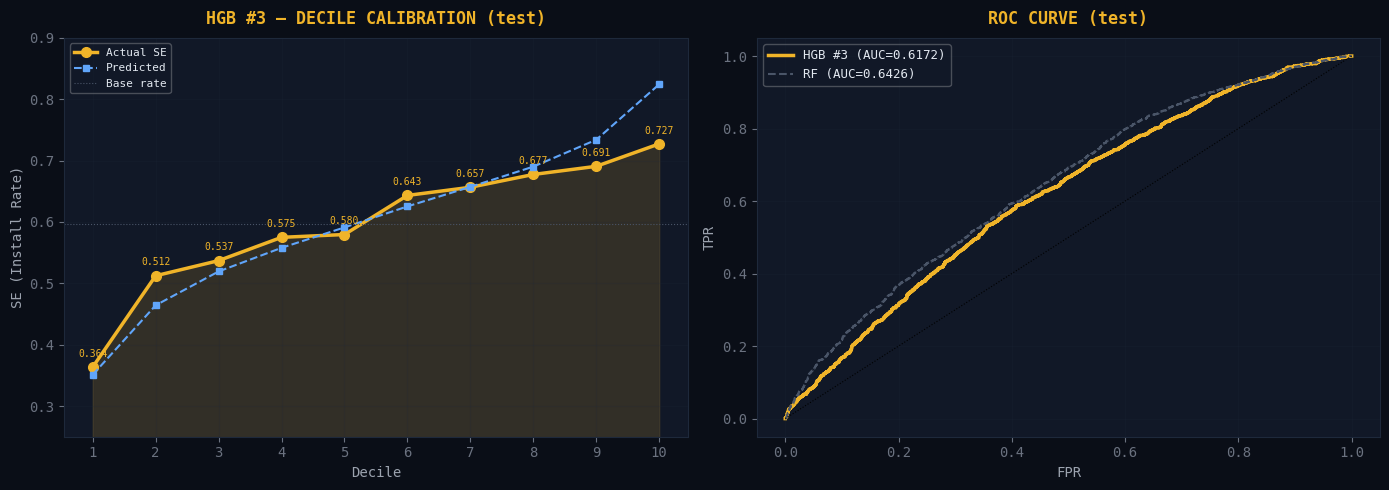

          n  inst   pmean      se
decile                           
1       528   192  0.3510  0.3636
2       527   270  0.4642  0.5123
3       527   283  0.5194  0.5370
4       527   303  0.5578  0.5750
5       528   306  0.5911  0.5795
6       527   339  0.6254  0.6433
7       527   346  0.6572  0.6565
8       527   357  0.6902  0.6774
9       527   364  0.7339  0.6907
10      528   384  0.8243  0.7273


In [19]:
# ── DECILE CURVE ──
edf3 = pd.DataFrame({"y": y_test.values, "p": p3})
edf3["decile"] = pd.qcut(edf3["p"], q=10, labels=False, duplicates="drop") + 1
dtbl3 = edf3.groupby("decile").agg(n=("y","count"), inst=("y","sum"), pmean=("p","mean"))
dtbl3["se"] = dtbl3["inst"] / dtbl3["n"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

d = list(range(1, 11))
ax1.fill_between(d, dtbl3["se"].values, alpha=0.15, color=AMBER)
ax1.plot(d, dtbl3["se"].values, "o-", color=AMBER, linewidth=2.5, markersize=7, label="Actual SE")
ax1.plot(d, dtbl3["pmean"].values, "s--", color=BLUE, linewidth=1.5, markersize=5, label="Predicted")
ax1.axhline(y_test.mean(), color=GRAY, linestyle=":", linewidth=0.8, label="Base rate")
for i, se in enumerate(dtbl3["se"].values):
    ax1.annotate(f"{se:.3f}", (i+1, se), fontsize=7, ha="center", va="bottom",
                 xytext=(0, 6), textcoords="offset points", color=AMBER)
ax1.set_xlabel("Decile"); ax1.set_ylabel("SE (Install Rate)")
ax1.set_title("HGB #3 — DECILE CALIBRATION (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax1.set_xticks(d); ax1.legend(fontsize=8, framealpha=0.3); ax1.grid(alpha=0.2); ax1.set_ylim(0.25, 0.9)

# ── AUC CURVE ──
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, p3)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color=AMBER, linewidth=2.5, label=f"HGB #3 (AUC={roc_auc:.4f})")
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict(X_test))
ax2.plot(fpr_rf, tpr_rf, color=GRAY, linewidth=1.5, linestyle="--", label=f"RF (AUC={auc(fpr_rf, tpr_rf):.4f})")
ax2.plot([0,1], [0,1], ":", color="#000000", linewidth=0.8)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.set_title("ROC CURVE (test)", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax2.legend(fontsize=9, framealpha=0.3); ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()
print(dtbl3.round(4))